In [38]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.eda.mask_level_eda import (
    summarize_mask_folder,
    summarize_mask_file,
    plot_label_sizes_single_case,
    plot_dataset_nonzero_fraction,
    plot_label_frequency_across_files,
    plot_slice_occupancy,
    show_mask_slice,
)

from src.eda.visualize_masks import show_nifti_overlay_from_paths

In [39]:
config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

totalseg_root = Path(config["totalseg_root"])
public_root = Path(config["public_root"])

print("totalseg_root exists:", totalseg_root.exists(), totalseg_root)
print("public_root exists:", public_root.exists(), public_root)

totalseg_root exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\interim\public_same_format\totalsegmentator_ml
public_root exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI


In [40]:
all_summary_df, all_labels_df, mask_paths = summarize_mask_folder(totalseg_root)

print("number of mask files found:", len(mask_paths))
all_summary_df.head()

number of mask files found: 4


,file_name,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z,n_labels_present,label_ids_present,nonzero_voxels,...,slices_with_mask_axis2,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_size_x,bbox_size_y,bbox_size_z
0,case101_day20.nii.gz,266,266,144,1.5,1.5,3.0,28,"1,2,3,5,6,10,11,12,13,14,15,18,19,20,21,22,23,...",1589376,...,144,40,247,70,223,0,143,208,154,144
1,case101_day22.nii.gz,266,266,144,1.5,1.5,3.0,34,"1,2,3,5,6,10,11,12,13,14,15,18,19,20,21,22,23,...",1589420,...,144,22,239,68,217,0,143,218,150,144
2,case101_day26.nii.gz,266,266,144,1.5,1.5,3.0,32,"1,2,3,5,6,10,11,12,13,14,15,18,19,20,21,22,23,...",1600896,...,144,14,243,68,215,0,143,230,148,144
3,case9_day22.nii.gz,360,310,144,1.5,1.5,3.0,35,"1,2,3,5,6,7,10,11,12,13,15,16,18,19,20,21,22,2...",1423548,...,144,32,257,54,241,0,143,226,188,144


In [41]:
all_labels_df.head(20)

,label_id,label_name,voxel_count,fraction_of_labeled_voxels,fraction_of_all_voxels,file_name
0,10,lung_left,437892,0.275512,0.042978,case101_day20.nii.gz
1,11,lung_right,411572,0.258952,0.040394,case101_day20.nii.gz
2,5,liver,89560,0.056349,0.008790,case101_day20.nii.gz
3,15,colon,86224,0.054250,0.008463,case101_day20.nii.gz
4,6,stomach,85688,0.053913,0.008410,case101_day20.nii.gz
5,22,heart,75468,0.047483,0.007407,case101_day20.nii.gz
6,47,autochthon_right,53284,0.033525,0.005230,case101_day20.nii.gz
7,46,autochthon_left,52712,0.033165,0.005173,case101_day20.nii.gz
8,19,vertebrae,49004,0.030832,0.004810,case101_day20.nii.gz
9,1,spleen,32740,0.020599,0.003213,case101_day20.nii.gz


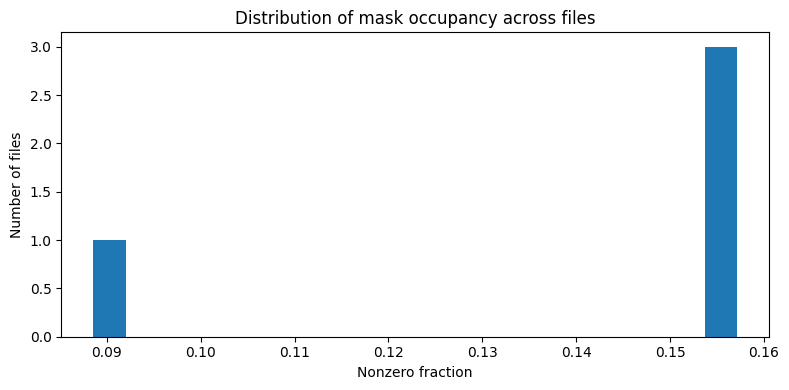

In [42]:
plot_dataset_nonzero_fraction(all_summary_df)

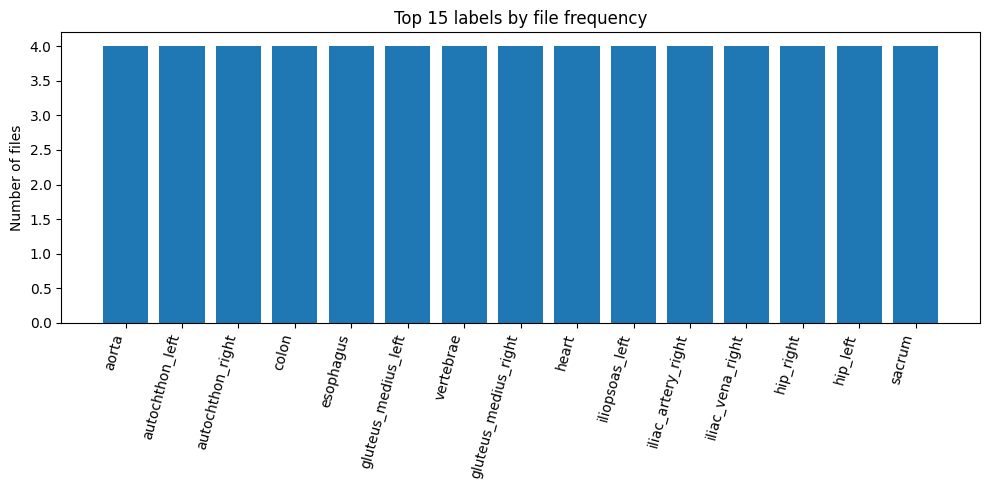

In [43]:
plot_label_frequency_across_files(all_labels_df, top_n=15)

In [44]:
example_mask_path = mask_paths[0]
print("example mask:", example_mask_path.name)

summary_df, labels_df, mask, img, label_map = summarize_mask_file(example_mask_path)

summary_df

example mask: case101_day20.nii.gz


,file_name,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z,n_labels_present,label_ids_present,nonzero_voxels,...,slices_with_mask_axis2,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_size_x,bbox_size_y,bbox_size_z
0,case101_day20.nii.gz,266,266,144,1.5,1.5,3.0,28,"1,2,3,5,6,10,11,12,13,14,15,18,19,20,21,22,23,...",1589376,...,144,40,247,70,223,0,143,208,154,144


In [45]:
labels_df.head(20)

,label_id,label_name,voxel_count,fraction_of_labeled_voxels,fraction_of_all_voxels
0,10,lung_left,437892,0.275512,0.042978
1,11,lung_right,411572,0.258952,0.040394
2,5,liver,89560,0.056349,0.008790
3,15,colon,86224,0.054250,0.008463
4,6,stomach,85688,0.053913,0.008410
5,22,heart,75468,0.047483,0.007407
6,47,autochthon_right,53284,0.033525,0.005230
7,46,autochthon_left,52712,0.033165,0.005173
8,19,vertebrae,49004,0.030832,0.004810
9,1,spleen,32740,0.020599,0.003213


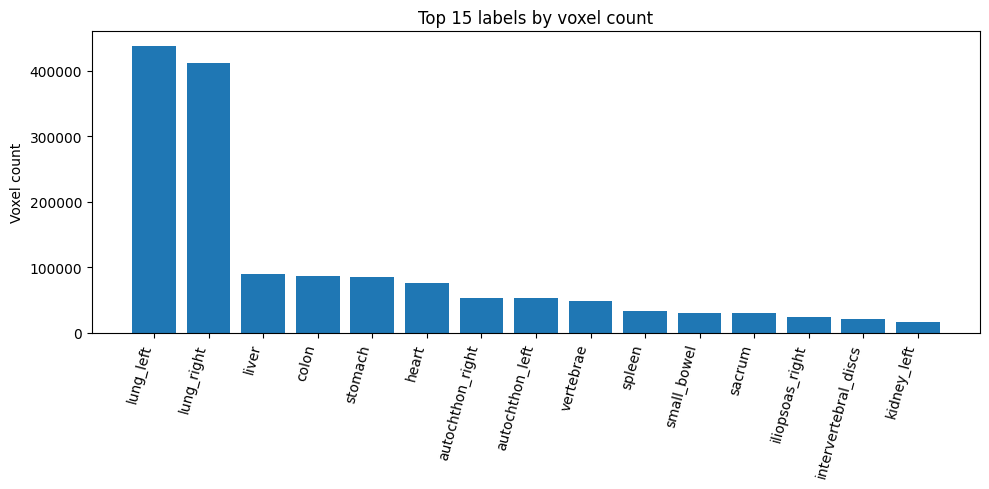

In [46]:
plot_label_sizes_single_case(labels_df, top_n=15)

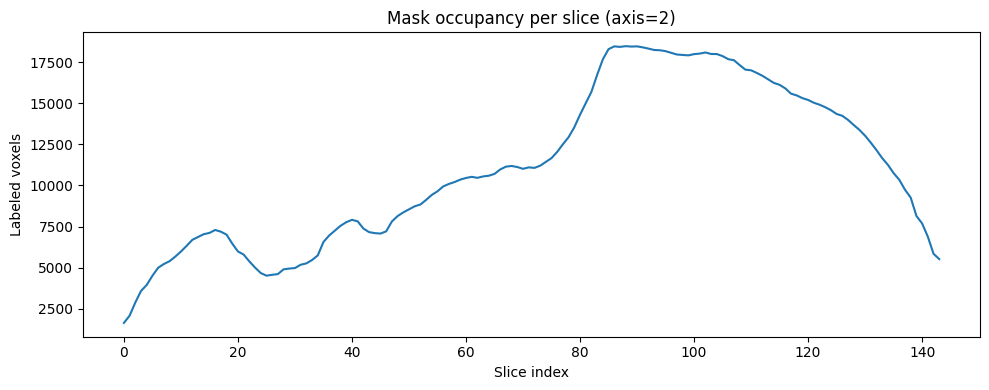

In [47]:
plot_slice_occupancy(mask, axis=2)

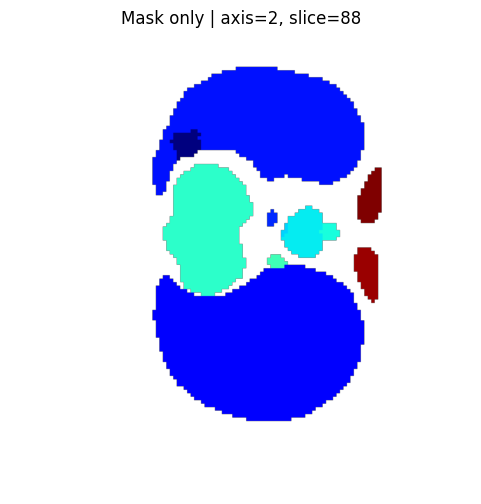

In [48]:
show_mask_slice(mask, axis=2)

scan exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI\case101_day20.nii.gz
mask exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\interim\public_same_format\totalsegmentator_ml\case101_day20.nii.gz


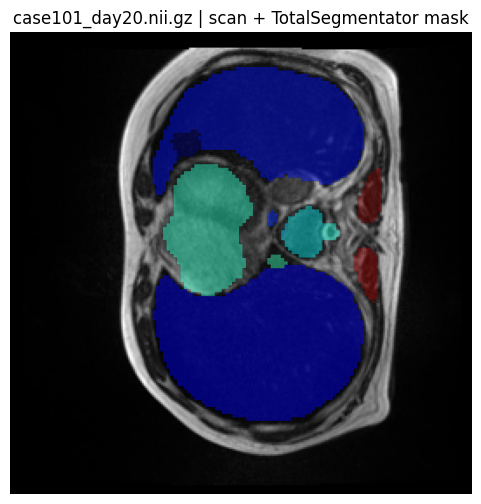

In [49]:
case_name = example_mask_path.name
scan_path = public_root / case_name

print("scan exists:", scan_path.exists(), scan_path)
print("mask exists:", example_mask_path.exists(), example_mask_path)

show_nifti_overlay_from_paths(
    scan_path=scan_path,
    mask_path=example_mask_path,
    axis=2,
    slice_idx=None,
    title=f"{case_name} | scan + TotalSegmentator mask"
)

In [50]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.eda.mask_level_eda as mask_level_eda
importlib.reload(mask_level_eda)

print("module file:", mask_level_eda.__file__)
print("has GI_LABELS_TOTAL_MR:", hasattr(mask_level_eda, "GI_LABELS_TOTAL_MR"))
print("GI_LABELS_TOTAL_MR:", getattr(mask_level_eda, "GI_LABELS_TOTAL_MR", None))

module file: C:\Users\P102832\Downloads\thesis_segmentation\src\eda\mask_level_eda.py
has GI_LABELS_TOTAL_MR: True
GI_LABELS_TOTAL_MR: {6: 'stomach', 13: 'small_bowel', 15: 'colon'}


In [51]:
from src.eda.mask_level_eda import (
    GI_LABELS_TOTAL_MR,
    summarize_selected_labels_folder,
    summarize_selected_labels_file,
    plot_selected_label_sizes_single_case,
    plot_selected_label_volumes_single_case,
    plot_selected_label_frequency_across_files,
)

In [52]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.eda.mask_level_eda import (
    GI_LABELS_TOTAL_MR,
    summarize_selected_labels_folder,
    summarize_selected_labels_file,
    plot_selected_label_sizes_single_case,
    plot_selected_label_volumes_single_case,
    plot_selected_label_frequency_across_files,
)

from src.eda.visualize_masks import show_nifti_overlay_from_paths

In [53]:
config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

totalseg_root = Path(config["totalseg_root"])
public_root = Path(config["public_root"])

gi_summary_df, gi_labels_df, gi_spans_df, mask_paths = summarize_selected_labels_folder(
    totalseg_root,
    selected_labels=GI_LABELS_TOTAL_MR,
)

print("number of mask files found:", len(mask_paths))
gi_summary_df

number of mask files found: 4


,file_name,shape_x,shape_y,shape_z,n_selected_labels_present,selected_nonzero_voxels,selected_nonzero_fraction
0,case101_day20.nii.gz,266,266,144,3,201980,0.019824
1,case101_day22.nii.gz,266,266,144,3,220428,0.021634
2,case101_day26.nii.gz,266,266,144,3,251912,0.024724
3,case9_day22.nii.gz,360,310,144,3,200272,0.012462


In [54]:
gi_labels_df

,label_id,label_name,voxel_count,present,fraction_of_selected_labeled_voxels,fraction_of_all_voxels,volume_mm3,volume_ml,file_name
0,15,colon,86224,True,0.426894,0.008463,582012.0,582.012,case101_day20.nii.gz
1,6,stomach,85688,True,0.424240,0.008410,578394.0,578.394,case101_day20.nii.gz
2,13,small_bowel,30068,True,0.148866,0.002951,202959.0,202.959,case101_day20.nii.gz
3,15,colon,89688,True,0.406881,0.008803,605394.0,605.394,case101_day22.nii.gz
4,6,stomach,75908,True,0.344366,0.007450,512379.0,512.379,case101_day22.nii.gz
5,13,small_bowel,54832,True,0.248752,0.005382,370116.0,370.116,case101_day22.nii.gz
6,15,colon,100708,True,0.399775,0.009884,679779.0,679.779,case101_day26.nii.gz
7,6,stomach,82592,True,0.327861,0.008106,557496.0,557.496,case101_day26.nii.gz
8,13,small_bowel,68612,True,0.272365,0.006734,463131.0,463.131,case101_day26.nii.gz
9,15,colon,99880,True,0.498722,0.006215,674190.0,674.190,case9_day22.nii.gz


In [55]:
gi_spans_df

,label_id,label_name,first_slice,last_slice,n_slices_present,best_slice,file_name
0,6,stomach,46,80,35,67,case101_day20.nii.gz
1,13,small_bowel,0,45,46,7,case101_day20.nii.gz
2,15,colon,12,74,63,39,case101_day20.nii.gz
3,6,stomach,50,86,37,71,case101_day22.nii.gz
4,13,small_bowel,0,63,56,2,case101_day22.nii.gz
5,15,colon,6,70,65,44,case101_day22.nii.gz
6,6,stomach,49,86,38,67,case101_day26.nii.gz
7,13,small_bowel,0,61,58,5,case101_day26.nii.gz
8,15,colon,8,77,70,42,case101_day26.nii.gz
9,6,stomach,72,103,32,81,case9_day22.nii.gz


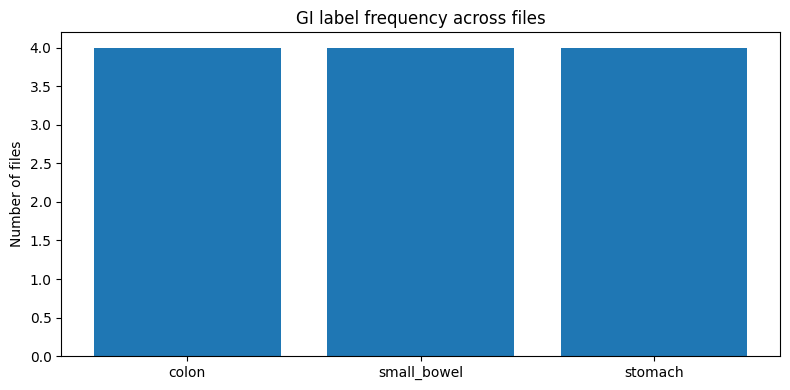

In [56]:
plot_selected_label_frequency_across_files(gi_labels_df)

In [57]:
example_mask_path = mask_paths[0]

single_summary_df, single_labels_df, single_spans_df, gi_mask, gi_img = summarize_selected_labels_file(
    example_mask_path,
    selected_labels=GI_LABELS_TOTAL_MR,
)

single_summary_df

,file_name,shape_x,shape_y,shape_z,n_selected_labels_present,selected_nonzero_voxels,selected_nonzero_fraction
0,case101_day20.nii.gz,266,266,144,3,201980,0.019824


In [58]:
single_labels_df

,label_id,label_name,voxel_count,present,fraction_of_selected_labeled_voxels,fraction_of_all_voxels,volume_mm3,volume_ml
0,15,colon,86224,True,0.426894,0.008463,582012.0,582.012
1,6,stomach,85688,True,0.424240,0.008410,578394.0,578.394
2,13,small_bowel,30068,True,0.148866,0.002951,202959.0,202.959


In [59]:
single_spans_df

,label_id,label_name,first_slice,last_slice,n_slices_present,best_slice
0,6,stomach,46,80,35,67
1,13,small_bowel,0,45,46,7
2,15,colon,12,74,63,39


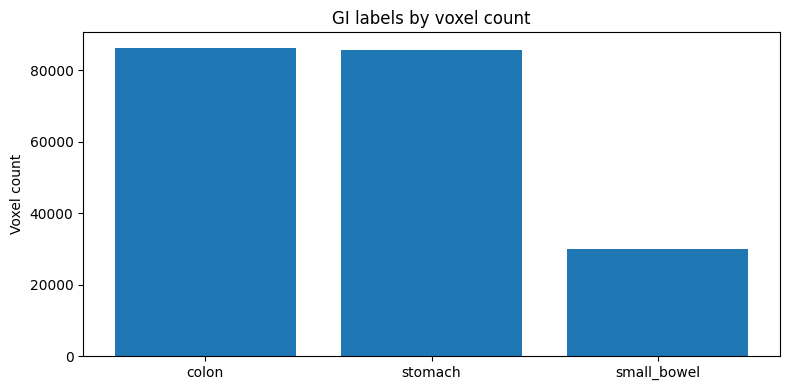

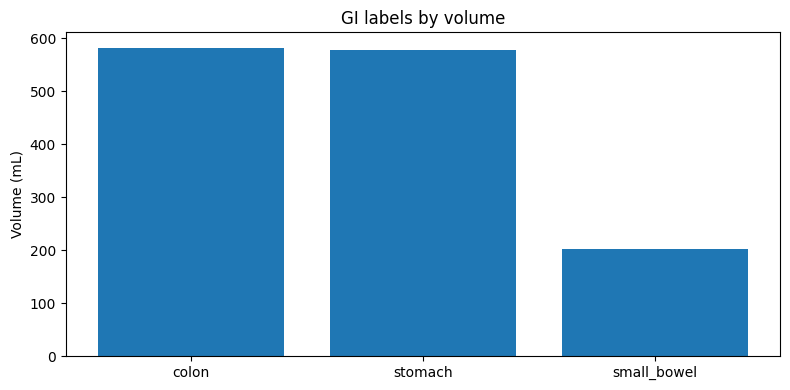

In [60]:
plot_selected_label_sizes_single_case(single_labels_df)
plot_selected_label_volumes_single_case(single_labels_df)

In [61]:
import importlib
import src.eda.visualize_masks as visualize_masks

importlib.reload(visualize_masks)

from src.eda.visualize_masks import load_nifti, show_nifti_overlay_from_arrays

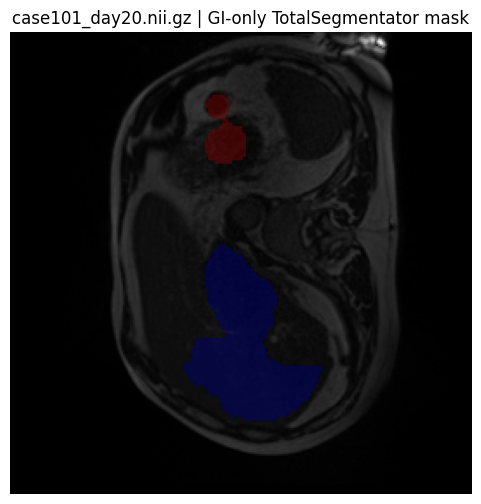

In [62]:
from src.eda.visualize_masks import load_nifti, show_nifti_overlay_from_arrays

case_name = example_mask_path.name
scan_path = public_root / case_name

scan_volume, _ = load_nifti(scan_path)

show_nifti_overlay_from_arrays(
    scan_volume=scan_volume,
    mask_volume=gi_mask,
    axis=2,
    slice_idx=None,
    title=f"{case_name} | GI-only TotalSegmentator mask"
)

In [63]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.eda.mask_level_eda as mask_level_eda
importlib.reload(mask_level_eda)

print(mask_level_eda.__file__)
print(hasattr(mask_level_eda, "build_case_gi_summary_table"))
print(hasattr(mask_level_eda, "build_case_gi_summary_sentence"))
print(hasattr(mask_level_eda, "get_label_id_by_name"))
print(hasattr(mask_level_eda, "extract_single_label_mask"))

C:\Users\P102832\Downloads\thesis_segmentation\src\eda\mask_level_eda.py
True
True
True
True


In [64]:
from src.eda.mask_level_eda import (
    GI_LABELS_TOTAL_MR,
    summarize_selected_labels_file,
    summarize_selected_labels_folder,
    build_case_gi_summary_table,
    build_case_gi_summary_sentence,
    get_label_id_by_name,
    extract_single_label_mask,
)

In [65]:
case_name = example_mask_path.name

case_gi_summary_table = build_case_gi_summary_table(
    single_labels_df,
    single_spans_df,
    organ_order=("colon", "stomach", "small_bowel"),
)

case_gi_summary_sentence = build_case_gi_summary_sentence(
    single_labels_df,
    single_spans_df,
    file_name=case_name,
    organ_order=("colon", "stomach", "small_bowel"),
)

print(case_gi_summary_sentence)
case_gi_summary_table

case101_day20.nii.gz: colon 582.0 mL across 63 slices; stomach 578.4 mL across 35 slices; small_bowel 203.0 mL across 46 slices.


,label_id,label_name,voxel_count,volume_ml,first_slice,last_slice,n_slices_present,best_slice
0,15,colon,86224,582.012,12,74,63,39
1,6,stomach,85688,578.394,46,80,35,67
2,13,small_bowel,30068,202.959,0,45,46,7


stomach: label_id=6, best_slice=67


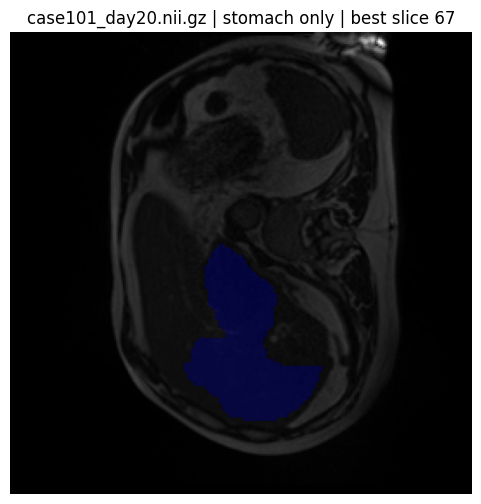

small_bowel: label_id=13, best_slice=7


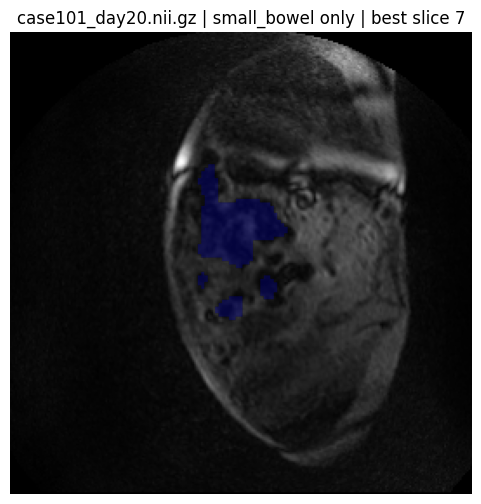

colon: label_id=15, best_slice=39


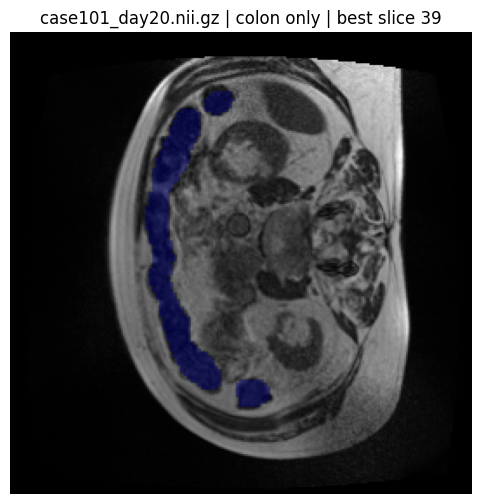

In [66]:
case_name = example_mask_path.name
scan_path = public_root / case_name

scan_volume, _ = load_nifti(scan_path)

organ_order = ["stomach", "small_bowel", "colon"]

for organ_name in organ_order:
    label_id = get_label_id_by_name(GI_LABELS_TOTAL_MR, organ_name)

    organ_mask = extract_single_label_mask(gi_mask, label_id)

    organ_best_slice = int(
        single_spans_df.loc[single_spans_df["label_name"] == organ_name, "best_slice"].iloc[0]
    )

    print(f"{organ_name}: label_id={label_id}, best_slice={organ_best_slice}")

    show_nifti_overlay_from_arrays(
        scan_volume=scan_volume,
        mask_volume=organ_mask,
        axis=2,
        slice_idx=organ_best_slice,
        title=f"{case_name} | {organ_name} only | best slice {organ_best_slice}"
    )

In [67]:
import pandas as pd

all_case_summaries = []

for mask_path in mask_paths:
    case_name = mask_path.name

    single_summary_df, single_labels_df, single_spans_df, gi_mask, gi_img = summarize_selected_labels_file(
        mask_path,
        selected_labels=GI_LABELS_TOTAL_MR,
    )

    sentence = build_case_gi_summary_sentence(
        single_labels_df,
        single_spans_df,
        file_name=case_name,
        organ_order=("colon", "stomach", "small_bowel"),
    )

    case_table = build_case_gi_summary_table(
        single_labels_df,
        single_spans_df,
        organ_order=("colon", "stomach", "small_bowel"),
    ).copy()

    wide_row = {"file_name": case_name, "summary_sentence": sentence}

    for _, row in case_table.iterrows():
        organ = row["label_name"]
        wide_row[f"{organ}_voxel_count"] = int(row["voxel_count"])
        wide_row[f"{organ}_volume_ml"] = float(row["volume_ml"])
        wide_row[f"{organ}_first_slice"] = int(row["first_slice"])
        wide_row[f"{organ}_last_slice"] = int(row["last_slice"])
        wide_row[f"{organ}_n_slices_present"] = int(row["n_slices_present"])
        wide_row[f"{organ}_best_slice"] = int(row["best_slice"])

    all_case_summaries.append(wide_row)

all_case_summary_df = pd.DataFrame(all_case_summaries)
all_case_summary_df

,file_name,summary_sentence,colon_voxel_count,colon_volume_ml,colon_first_slice,colon_last_slice,colon_n_slices_present,colon_best_slice,stomach_voxel_count,stomach_volume_ml,stomach_first_slice,stomach_last_slice,stomach_n_slices_present,stomach_best_slice,small_bowel_voxel_count,small_bowel_volume_ml,small_bowel_first_slice,small_bowel_last_slice,small_bowel_n_slices_present,small_bowel_best_slice
0,case101_day20.nii.gz,case101_day20.nii.gz: colon 582.0 mL across 63...,86224,582.012,12,74,63,39,85688,578.394,46,80,35,67,30068,202.959,0,45,46,7
1,case101_day22.nii.gz,case101_day22.nii.gz: colon 605.4 mL across 65...,89688,605.394,6,70,65,44,75908,512.379,50,86,37,71,54832,370.116,0,63,56,2
2,case101_day26.nii.gz,case101_day26.nii.gz: colon 679.8 mL across 70...,100708,679.779,8,77,70,42,82592,557.496,49,86,38,67,68612,463.131,0,61,58,5
3,case9_day22.nii.gz,case9_day22.nii.gz: colon 674.2 mL across 80 s...,99880,674.190,2,82,80,55,29992,202.446,72,103,32,81,70400,475.200,0,78,72,23


In [68]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.eda.totalseg_mask_qc import (
    REQUIRED_TOTAL_MR_ORGANS,
    check_all_scans_have_required_masks,
    print_qc_result,
)

In [69]:
config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

scan_root = Path(config["public_root"])
mask_root = Path(config["totalseg_root"])

print("scan_root:", scan_root)
print("mask_root:", mask_root)
print("scan_root exists:", scan_root.exists())
print("mask_root exists:", mask_root.exists())
print("required organs:", REQUIRED_TOTAL_MR_ORGANS)

scan_root: C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI
mask_root: C:\Users\P102832\Downloads\thesis_segmentation\data\interim\public_same_format\totalsegmentator_ml
scan_root exists: True
mask_root exists: True
required organs: {'spleen': [1], 'kidney_right': [2], 'kidney_left': [3], 'stomach': [6], 'small_bowel': [13], 'duodenum': [14], 'colon': [15]}


In [70]:
qc_summary_df, organ_presence_df, extra_masks_df = check_all_scans_have_required_masks(
    scan_root=scan_root,
    mask_root=mask_root,
    required_organs=REQUIRED_TOTAL_MR_ORGANS,
)

print_qc_result(qc_summary_df, organ_presence_df, extra_masks_df)

STRICT TOTAL-SEGMENTATOR MASK QC
--------------------------------
Number of scans checked: 274
Scans without matching mask: 0
Files missing at least one required organ: 4
Total missing organ entries: 4
Extra mask files without matching scan: 0

FAIL: some scans/masks are incomplete. Inspect the tables below.


In [71]:
failed_files_df = qc_summary_df[
    ~qc_summary_df["all_required_organs_present"]
].copy()

failed_files_df

,file_name,scan_exists,mask_exists,all_required_organs_present,n_missing_organs,missing_organs
101,case144_day14.nii.gz,True,True,False,1,duodenum
192,case44_day0.nii.gz,True,True,False,1,duodenum
237,case78_day18.nii.gz,True,True,False,1,duodenum
273,case9_day22.nii.gz,True,True,False,1,duodenum


In [72]:
missing_organs_df = organ_presence_df[
    ~organ_presence_df["present"]
].copy()

missing_organs_df

,file_name,organ_name,label_ids,present,voxel_count,volume_mm3,volume_ml,first_slice,last_slice,n_slices_present,best_slice
712,case144_day14.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,NaN,0,NaN
1349,case44_day0.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,NaN,0,NaN
1664,case78_day18.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,NaN,0,NaN
1916,case9_day22.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,NaN,0,NaN


In [73]:
organ_presence_counts_df = (
    organ_presence_df
    .groupby("organ_name")["present"]
    .agg(
        n_present="sum",
        n_total="count"
    )
    .reset_index()
)

organ_presence_counts_df["n_missing"] = (
    organ_presence_counts_df["n_total"] - organ_presence_counts_df["n_present"]
)

organ_presence_counts_df

,organ_name,n_present,n_total,n_missing
0,colon,274,274,0
1,duodenum,270,274,4
2,kidney_left,274,274,0
3,kidney_right,274,274,0
4,small_bowel,274,274,0
5,spleen,274,274,0
6,stomach,274,274,0


In [74]:
from pathlib import Path
import json
import sys
import pandas as pd

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.eda.totalseg_organ_level_eda import (
    SELECTED_TOTAL_MR_ORGANS,
    summarize_organs_in_folder,
    build_presence_counts,
    build_missing_organs_table,
    build_volume_stats,
    build_case_wide_summary,
    plot_missing_counts,
    plot_volume_boxplot,
    plot_volume_histogram_for_organ,
    print_strict_eda_summary,
)

In [75]:
organ_long_df, mask_paths = summarize_organs_in_folder(
    mask_root=mask_root,
    selected_organs=SELECTED_TOTAL_MR_ORGANS,
)

presence_counts_df = build_presence_counts(organ_long_df)
missing_organs_df = build_missing_organs_table(organ_long_df)
volume_stats_df = build_volume_stats(organ_long_df)
case_wide_summary_df = build_case_wide_summary(organ_long_df)

print_strict_eda_summary(
    organ_long_df=organ_long_df,
    presence_counts_df=presence_counts_df,
    missing_organs_df=missing_organs_df,
)

STRICT ORGAN-LEVEL TOTAL-SEGMENTATOR EDA SUMMARY
------------------------------------------------
Number of mask files checked: 274
Number of selected organs checked: 7
Total missing organ entries: 4

These are treated as NOT SEGMENTED, not as true zero-volume anatomy.

Missing counts by organ:
     organ_name  n_present  n_total  n_missing
0      duodenum        270      274          4
1         colon        274      274          0
2   kidney_left        274      274          0
3  kidney_right        274      274          0
4   small_bowel        274      274          0
5        spleen        274      274          0
6       stomach        274      274          0


In [76]:
presence_counts_df

,organ_name,n_present,n_total,n_missing,missing_fraction
0,duodenum,270,274,4,0.014599
1,colon,274,274,0,0.000000
2,kidney_left,274,274,0,0.000000
3,kidney_right,274,274,0,0.000000
4,small_bowel,274,274,0,0.000000
5,spleen,274,274,0,0.000000
6,stomach,274,274,0,0.000000


In [77]:
missing_organs_df

,file_name,organ_name,label_ids,present,voxel_count,volume_mm3,volume_ml,volume_ml_for_stats,fraction_of_scan_voxels,shape_x,...,best_slice,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_size_x,bbox_size_y,bbox_size_z
0,case144_day14.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,0.0,266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,case44_day0.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,0.0,266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
2,case78_day18.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,0.0,360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
3,case9_day22.nii.gz,duodenum,14,False,0,0.0,0.0,NaN,0.0,360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0


In [78]:
volume_stats_df

,organ_name,n_present,mean_ml,std_ml,min_ml,median_ml,max_ml
0,colon,274,543.688051,215.891957,119.79900,502.318125,1477.62900
1,duodenum,270,16.563370,11.997896,0.02700,13.979250,71.16525
2,kidney_left,274,124.366036,32.412584,26.91900,119.424375,247.96800
3,kidney_right,274,123.852832,34.029359,20.12850,121.678875,222.27075
4,small_bowel,274,461.287213,227.318976,51.42825,437.339250,1049.24700
5,spleen,274,595.656794,182.233820,161.75025,601.094250,1176.47775
6,stomach,274,263.102541,147.239465,27.70875,238.892625,674.80425


In [79]:
case_wide_summary_df.head()

,file_name,colon_volume_ml,duodenum_volume_ml,kidney_left_volume_ml,kidney_right_volume_ml,small_bowel_volume_ml,spleen_volume_ml,stomach_volume_ml,colon_present,duodenum_present,kidney_left_present,kidney_right_present,small_bowel_present,spleen_present,stomach_present
0,case101_day20.nii.gz,582.01200,4.53600,112.53600,68.121,202.95900,220.99500,578.3940,True,True,True,True,True,True,True
1,case101_day22.nii.gz,605.39400,5.80500,120.31200,79.461,370.11600,325.45800,512.3790,True,True,True,True,True,True,True
2,case101_day26.nii.gz,679.77900,10.85400,118.50300,86.535,463.13100,311.87700,557.4960,True,True,True,True,True,True,True
3,case101_day32.nii.gz,477.38025,13.83075,120.60225,85.671,276.74325,522.70650,550.5570,True,True,True,True,True,True,True
4,case102_day0.nii.gz,457.81875,4.72500,103.09950,97.956,160.86600,267.36075,105.2865,True,True,True,True,True,True,True


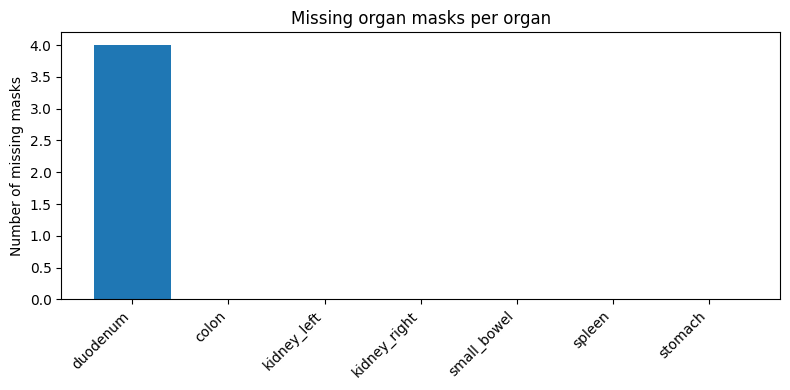

In [80]:
plot_missing_counts(presence_counts_df)

<Figure size 1000x500 with 0 Axes>

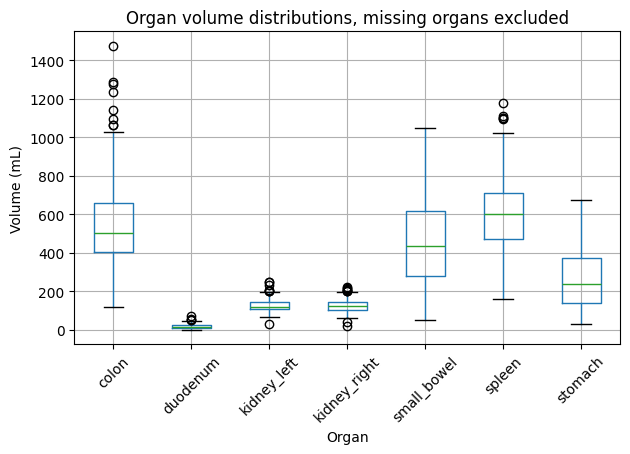

In [81]:
plot_volume_boxplot(organ_long_df)

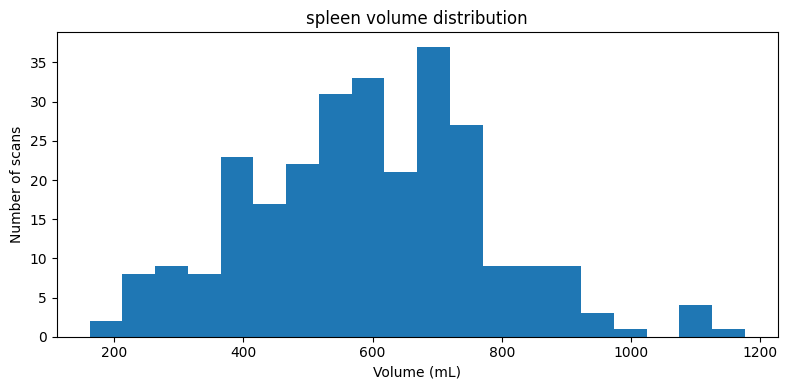

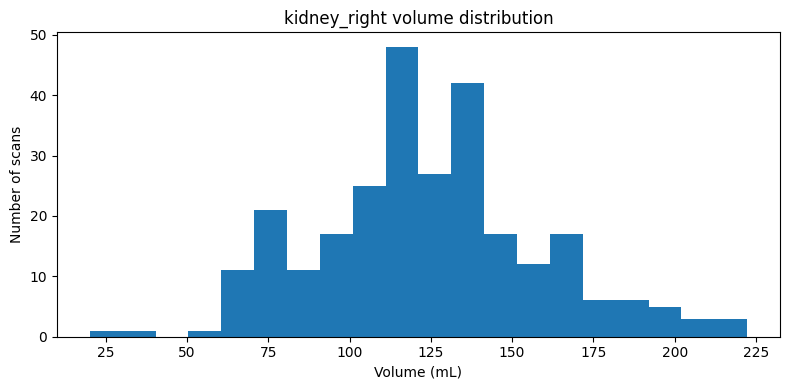

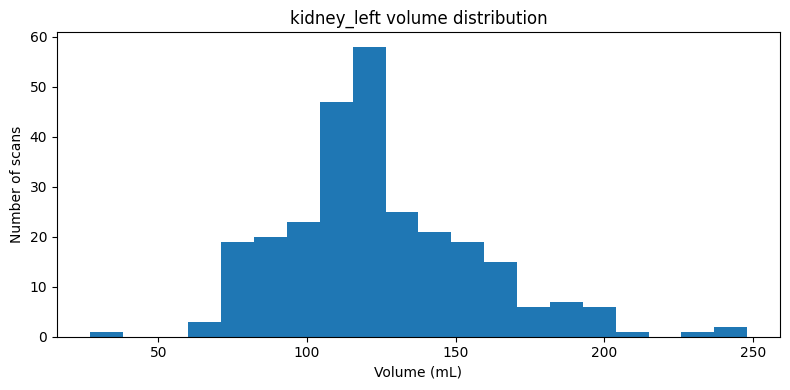

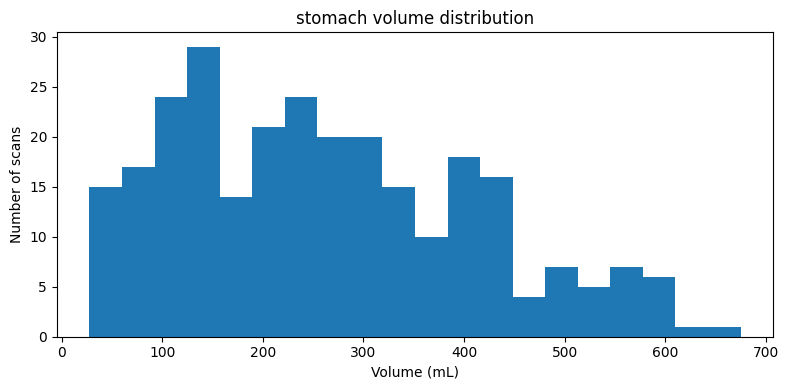

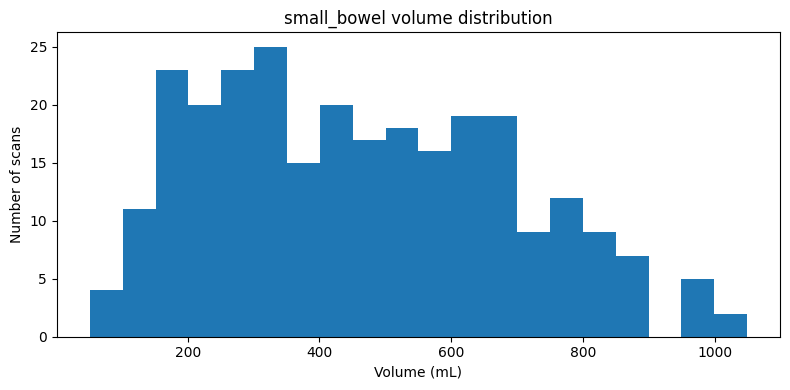

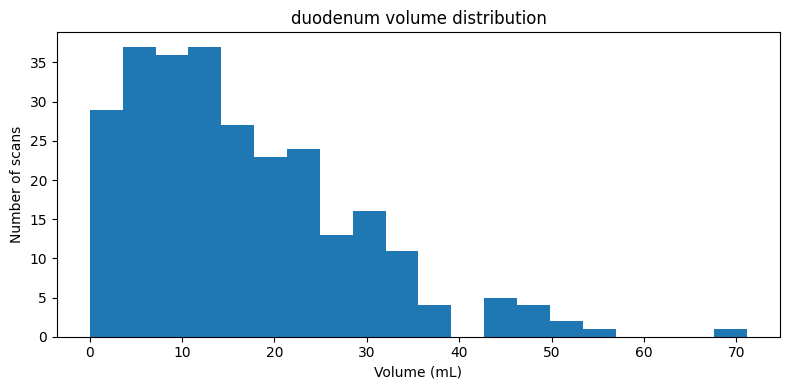

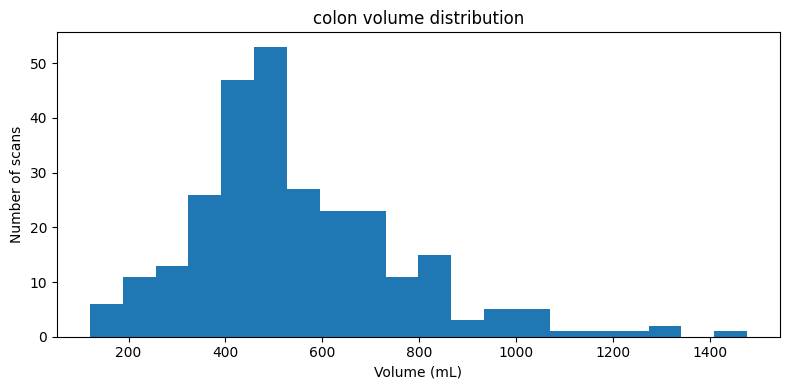

In [82]:
for organ_name in SELECTED_TOTAL_MR_ORGANS.keys():
    plot_volume_histogram_for_organ(organ_long_df, organ_name)

In [90]:
import importlib
import src.eda.totalseg_organ_level_eda as organ_eda

importlib.reload(organ_eda)

print("module file:", organ_eda.__file__)
print("has build_volume_outlier_table:", hasattr(organ_eda, "build_volume_outlier_table"))
print("has build_missing_qc_table:", hasattr(organ_eda, "build_missing_qc_table"))
print("has extract_organ_mask:", hasattr(organ_eda, "extract_organ_mask"))
print("has label_ids_from_string:", hasattr(organ_eda, "label_ids_from_string"))
print("has print_outlier_qc_summary:", hasattr(organ_eda, "print_outlier_qc_summary"))

module file: C:\Users\P102832\Downloads\thesis_segmentation\src\eda\totalseg_organ_level_eda.py
has build_volume_outlier_table: True
has build_missing_qc_table: True
has extract_organ_mask: True
has label_ids_from_string: True
has print_outlier_qc_summary: True


In [91]:
from src.eda.totalseg_organ_level_eda import (
    build_volume_outlier_table,
    build_missing_qc_table,
    extract_organ_mask,
    label_ids_from_string,
    print_outlier_qc_summary,
)

In [92]:
outlier_qc_df = build_volume_outlier_table(
    organ_long_df=organ_long_df,
    organs=[
        "stomach",
        "spleen",
        "kidney_left",
        "kidney_right",
        "duodenum",
        "colon",
        "small_bowel",
    ],
    n_smallest=1,
    n_largest=1,
)

missing_qc_df = build_missing_qc_table(organ_long_df)

print_outlier_qc_summary(outlier_qc_df, missing_qc_df)

outlier_qc_df

STRICT VISUAL OUTLIER QC SELECTION
----------------------------------
Number of volume outlier rows selected: 14
Number of missing organ rows selected: 4

Selected volume outliers:
            outlier_type             file_name    organ_name  \
0                largest  case134_day22.nii.gz         colon   
1   smallest_non_missing   case77_day20.nii.gz         colon   
2                largest  case107_day19.nii.gz      duodenum   
3   smallest_non_missing   case78_day22.nii.gz      duodenum   
4                largest  case145_day19.nii.gz   kidney_left   
5   smallest_non_missing   case65_day28.nii.gz   kidney_left   
6                largest  case122_day27.nii.gz  kidney_right   
7   smallest_non_missing   case65_day28.nii.gz  kidney_right   
8                largest  case119_day21.nii.gz   small_bowel   
9   smallest_non_missing   case65_day28.nii.gz   small_bowel   
10               largest    case65_day0.nii.gz        spleen   
11  smallest_non_missing    case15_day0.nii.gz     

,outlier_type,file_name,organ_name,label_ids,present,voxel_count,volume_ml,volume_ml_for_stats,first_slice,last_slice,n_slices_present,best_slice
0,largest,case134_day22.nii.gz,colon,15,True,218908,1477.62900,1477.62900,0.0,98.0,99,82.0
1,smallest_non_missing,case77_day20.nii.gz,colon,15,True,17748,119.79900,119.79900,0.0,52.0,42,25.0
2,largest,case107_day19.nii.gz,duodenum,14,True,10543,71.16525,71.16525,49.0,73.0,25,55.0
3,smallest_non_missing,case78_day22.nii.gz,duodenum,14,True,4,0.02700,0.02700,31.0,32.0,2,31.0
4,largest,case145_day19.nii.gz,kidney_left,3,True,36736,247.96800,247.96800,27.0,76.0,50,63.0
5,smallest_non_missing,case65_day28.nii.gz,kidney_left,3,True,3988,26.91900,26.91900,0.0,9.0,10,4.0
6,largest,case122_day27.nii.gz,kidney_right,2,True,32929,222.27075,222.27075,27.0,70.0,44,58.0
7,smallest_non_missing,case65_day28.nii.gz,kidney_right,2,True,2982,20.12850,20.12850,3.0,15.0,13,10.0
8,largest,case119_day21.nii.gz,small_bowel,13,True,155444,1049.24700,1049.24700,0.0,69.0,70,44.0
9,smallest_non_missing,case65_day28.nii.gz,small_bowel,13,True,7619,51.42825,51.42825,0.0,35.0,33,20.0


In [94]:
missing_qc_df

,file_name,organ_name,label_ids,present,voxel_count,volume_ml,first_slice,last_slice,n_slices_present,best_slice
0,case144_day14.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
1,case44_day0.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
2,case78_day18.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
3,case9_day22.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN


In [97]:
from src.eda.mask_level_eda import load_multilabel_mask
from src.eda.visualize_masks import load_nifti, show_nifti_overlay_from_arrays
from src.eda.totalseg_organ_level_eda import (
    extract_organ_mask,
    label_ids_from_string,
)
from pathlib import Path

In [98]:
def show_outlier_overlay(row, scan_root, mask_root, axis=2):
    """
    Show scan + organ mask overlay for one selected outlier row.
    """
    file_name = row["file_name"]
    organ_name = row["organ_name"]
    label_ids = label_ids_from_string(row["label_ids"])

    scan_path = Path(scan_root) / file_name
    mask_path = Path(mask_root) / file_name

    print("--------------------------------")
    print("file:", file_name)
    print("organ:", organ_name)
    print("outlier type:", row.get("outlier_type", "missing"))
    print("volume_ml:", row.get("volume_ml_for_stats", row.get("volume_ml", None)))
    print("best_slice:", row.get("best_slice", None))
    print("scan exists:", scan_path.exists())
    print("mask exists:", mask_path.exists())

    if not scan_path.exists():
        print("Scan file missing. Cannot show overlay.")
        return

    if not mask_path.exists():
        print("Mask file missing. Cannot show overlay.")
        return

    if not bool(row["present"]):
        print("This organ was not segmented. No organ overlay can be shown.")
        return

    scan_volume, _ = load_nifti(scan_path)
    mask_volume, _, _ = load_multilabel_mask(mask_path)

    organ_mask = extract_organ_mask(mask_volume, label_ids)

    best_slice = int(row["best_slice"])

    show_nifti_overlay_from_arrays(
        scan_volume=scan_volume,
        mask_volume=organ_mask,
        axis=axis,
        slice_idx=best_slice,
        title=f"{file_name} | {organ_name} | {row.get('outlier_type', 'QC')} | slice {best_slice}",
    )

--------------------------------
file: case134_day22.nii.gz
organ: colon
outlier type: largest
volume_ml: 1477.629
best_slice: 82.0
scan exists: True
mask exists: True


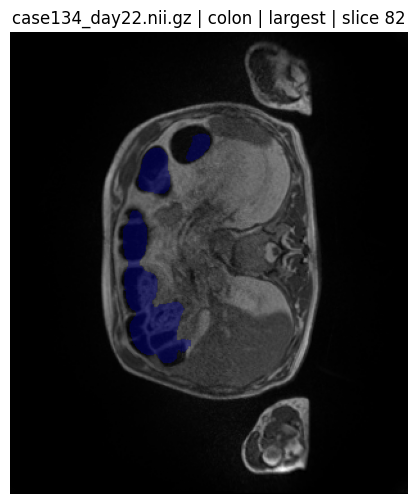

--------------------------------
file: case77_day20.nii.gz
organ: colon
outlier type: smallest_non_missing
volume_ml: 119.799
best_slice: 25.0
scan exists: True
mask exists: True


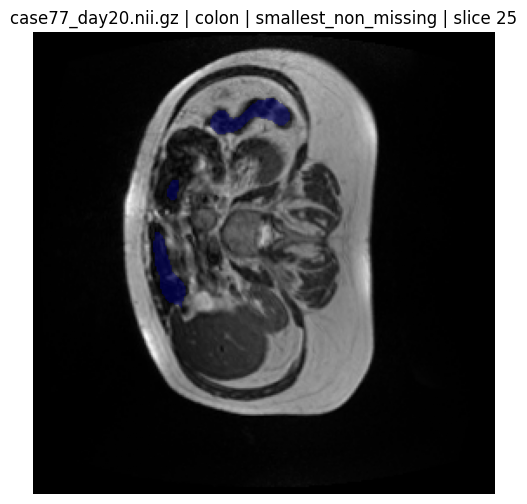

--------------------------------
file: case107_day19.nii.gz
organ: duodenum
outlier type: largest
volume_ml: 71.16525
best_slice: 55.0
scan exists: True
mask exists: True


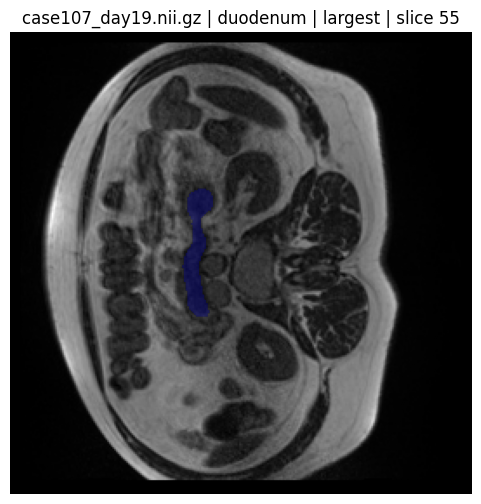

--------------------------------
file: case78_day22.nii.gz
organ: duodenum
outlier type: smallest_non_missing
volume_ml: 0.027
best_slice: 31.0
scan exists: True
mask exists: True


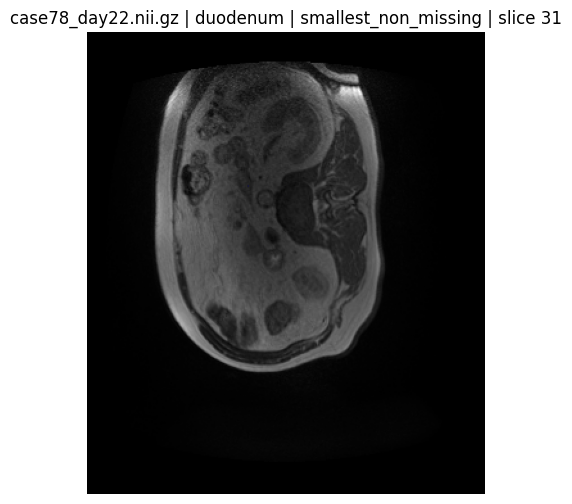

--------------------------------
file: case145_day19.nii.gz
organ: kidney_left
outlier type: largest
volume_ml: 247.968
best_slice: 63.0
scan exists: True
mask exists: True


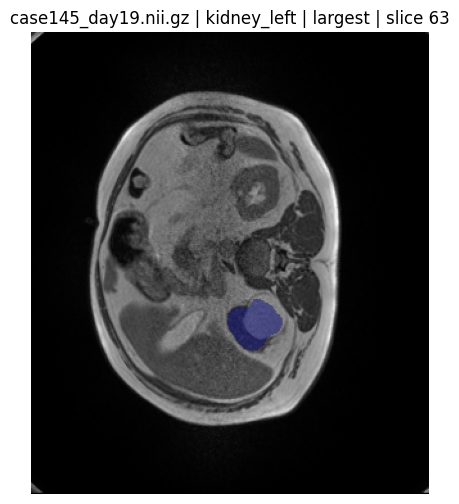

--------------------------------
file: case65_day28.nii.gz
organ: kidney_left
outlier type: smallest_non_missing
volume_ml: 26.919
best_slice: 4.0
scan exists: True
mask exists: True


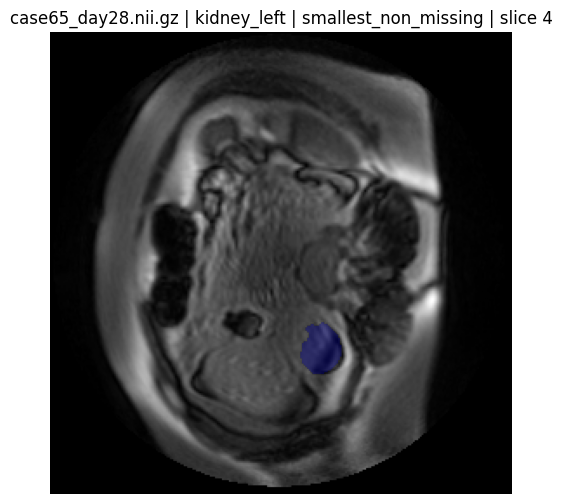

--------------------------------
file: case122_day27.nii.gz
organ: kidney_right
outlier type: largest
volume_ml: 222.27075
best_slice: 58.0
scan exists: True
mask exists: True


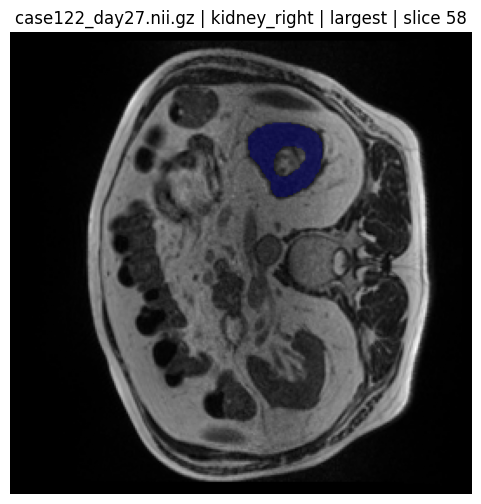

--------------------------------
file: case65_day28.nii.gz
organ: kidney_right
outlier type: smallest_non_missing
volume_ml: 20.1285
best_slice: 10.0
scan exists: True
mask exists: True


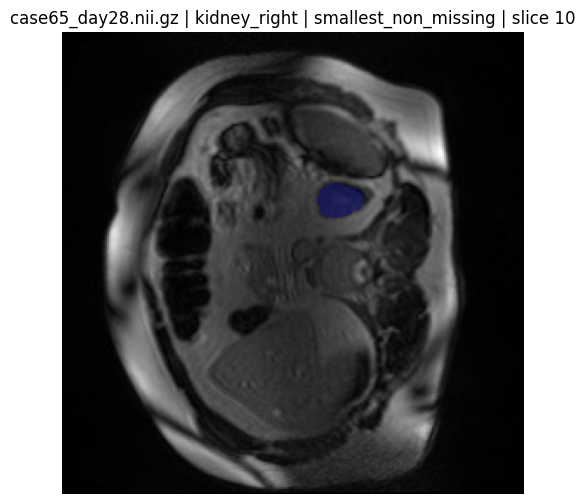

--------------------------------
file: case119_day21.nii.gz
organ: small_bowel
outlier type: largest
volume_ml: 1049.247
best_slice: 44.0
scan exists: True
mask exists: True


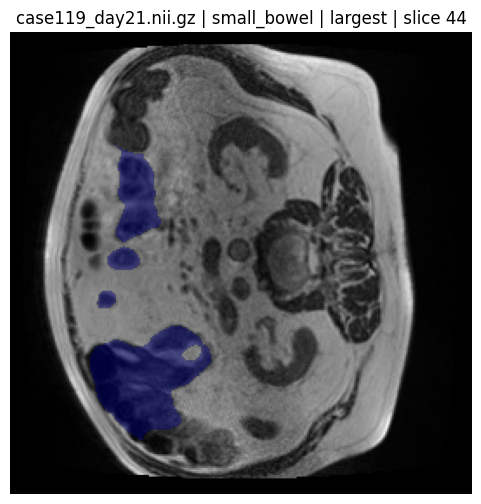

--------------------------------
file: case65_day28.nii.gz
organ: small_bowel
outlier type: smallest_non_missing
volume_ml: 51.42825
best_slice: 20.0
scan exists: True
mask exists: True


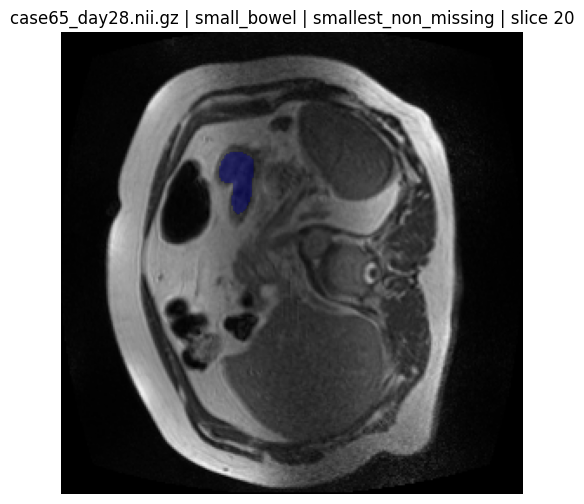

--------------------------------
file: case65_day0.nii.gz
organ: spleen
outlier type: largest
volume_ml: 1176.47775
best_slice: 62.0
scan exists: True
mask exists: True


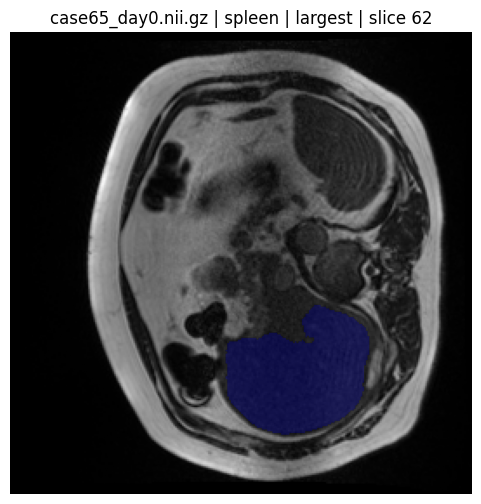

--------------------------------
file: case15_day0.nii.gz
organ: spleen
outlier type: smallest_non_missing
volume_ml: 161.75025
best_slice: 82.0
scan exists: True
mask exists: True


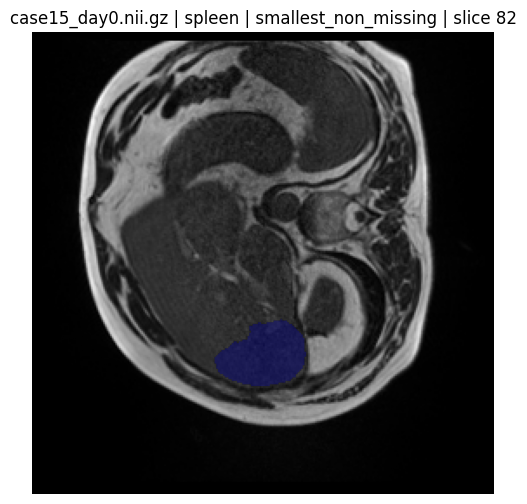

--------------------------------
file: case119_day21.nii.gz
organ: stomach
outlier type: largest
volume_ml: 674.80425
best_slice: 78.0
scan exists: True
mask exists: True


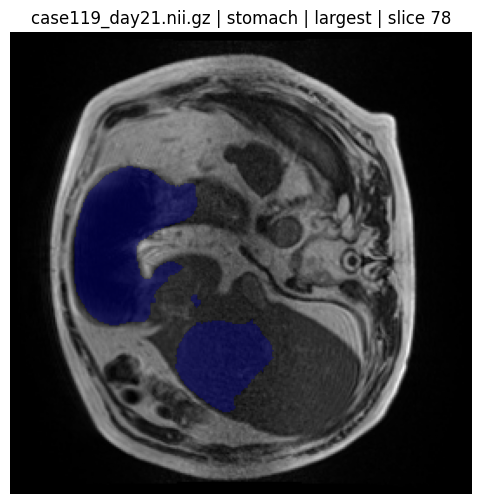

--------------------------------
file: case24_day25.nii.gz
organ: stomach
outlier type: smallest_non_missing
volume_ml: 27.70875
best_slice: 85.0
scan exists: True
mask exists: True


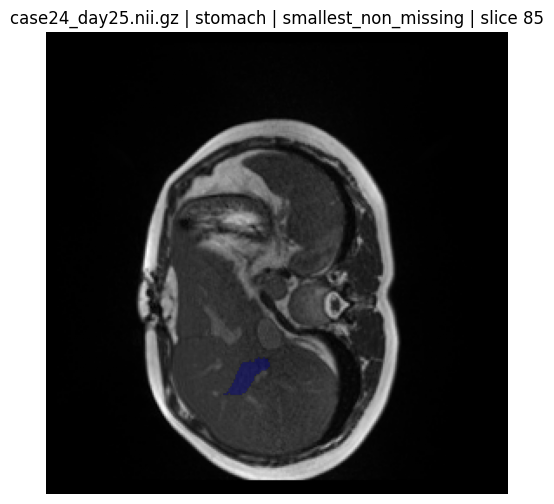

In [99]:
for _, row in outlier_qc_df.iterrows():
    show_outlier_overlay(
        row=row,
        scan_root=Path(config["public_root"]),
        mask_root=Path(config["totalseg_root"]),
        axis=2,
    )

In [100]:
missing_qc_df

,file_name,organ_name,label_ids,present,voxel_count,volume_ml,first_slice,last_slice,n_slices_present,best_slice
0,case144_day14.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
1,case44_day0.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
2,case78_day18.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN
3,case9_day22.nii.gz,duodenum,14,False,0,0.0,NaN,NaN,0,NaN


In [101]:
def show_scan_only_for_missing_case(row, scan_root, axis=2):
    file_name = row["file_name"]
    organ_name = row["organ_name"]

    scan_path = Path(scan_root) / file_name

    print("--------------------------------")
    print("file:", file_name)
    print("missing organ:", organ_name)
    print("scan exists:", scan_path.exists())

    if not scan_path.exists():
        print("Scan file missing. Cannot show scan.")
        return

    scan_volume, _ = load_nifti(scan_path)

    middle_slice = scan_volume.shape[axis] // 2

    if axis == 0:
        scan_slice = scan_volume[middle_slice, :, :]
    elif axis == 1:
        scan_slice = scan_volume[:, middle_slice, :]
    elif axis == 2:
        scan_slice = scan_volume[:, :, middle_slice]
    else:
        raise ValueError("axis must be 0, 1, or 2")

    scan_slice = scan_slice.astype("float32")
    scan_min = scan_slice.min()
    scan_max = scan_slice.max()

    if scan_max > scan_min:
        scan_slice = (scan_slice - scan_min) / (scan_max - scan_min)

    plt.figure(figsize=(6, 6))
    plt.imshow(scan_slice, cmap="gray", origin="lower")
    plt.title(f"{file_name} | missing {organ_name} | scan only | middle slice {middle_slice}")
    plt.axis("off")
    plt.show()

--------------------------------
file: case144_day14.nii.gz
missing organ: duodenum
scan exists: True


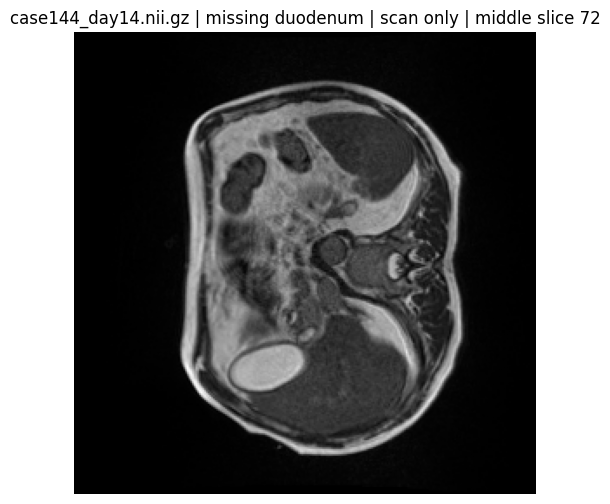

--------------------------------
file: case44_day0.nii.gz
missing organ: duodenum
scan exists: True


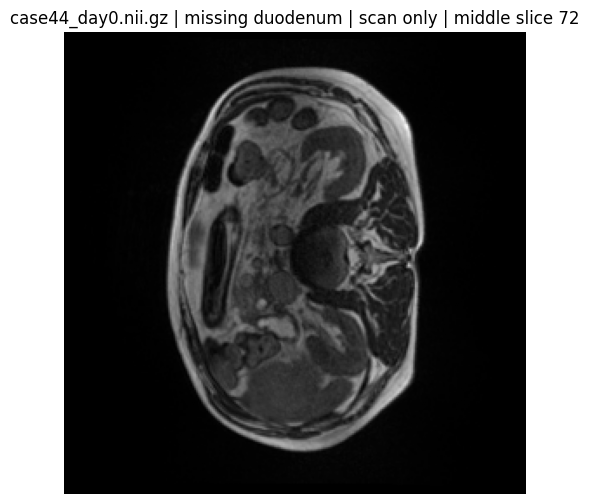

--------------------------------
file: case78_day18.nii.gz
missing organ: duodenum
scan exists: True


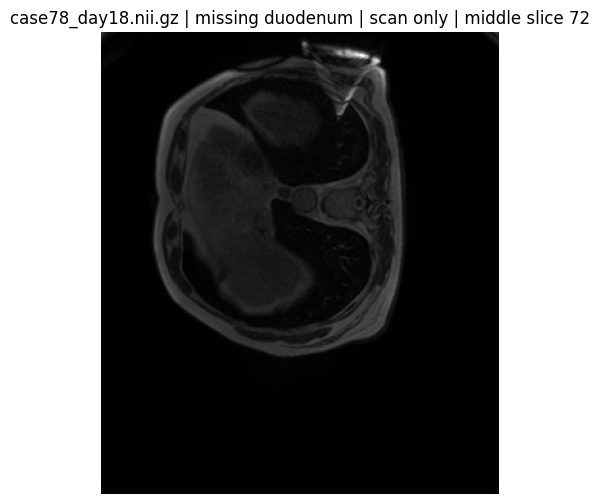

--------------------------------
file: case9_day22.nii.gz
missing organ: duodenum
scan exists: True


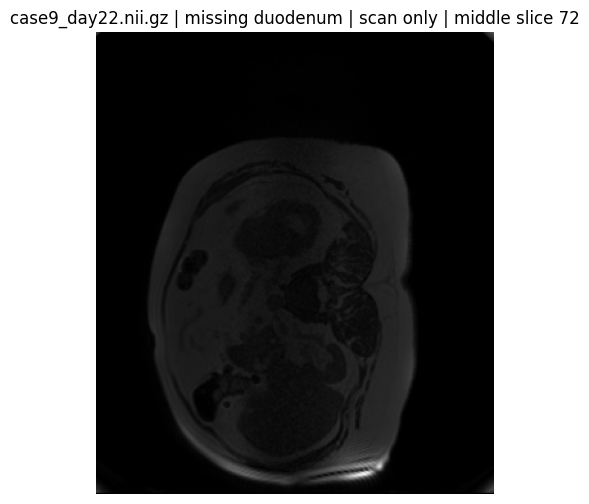

In [103]:
import matplotlib.pyplot as plt
for _, row in missing_qc_df.iterrows():
    show_scan_only_for_missing_case(
        row=row,
        scan_root=Path(config["public_root"]),
        axis=2,
    )

In [107]:
import importlib
import src.eda.totalseg_organ_level_eda as organ_eda

importlib.reload(organ_eda)

from src.eda.totalseg_organ_level_eda import (
    create_initial_qc_decision_table,
    apply_manual_qc_flags,
    apply_qc_to_organ_long_df,
    build_qc_filtered_volume_stats,
    build_qc_flag_counts,
)

In [108]:
qc_decision_df = create_initial_qc_decision_table(organ_long_df)
qc_decision_df = apply_manual_qc_flags(qc_decision_df)

organ_long_qc_df = apply_qc_to_organ_long_df(
    organ_long_df=organ_long_df,
    qc_df=qc_decision_df,
)

qc_filtered_volume_stats_df = build_qc_filtered_volume_stats(organ_long_qc_df)
qc_flag_counts_df = build_qc_flag_counts(qc_decision_df)

In [109]:
qc_decision_df[qc_decision_df["qc_flag"] != "ok"]

,file_name,organ_name,present,voxel_count,volume_ml,volume_ml_for_stats,n_slices_present,best_slice,qc_flag,qc_reason,use_for_volume_stats
255,case119_day21.nii.gz,stomach,True,99971,674.80425,674.80425,32,78.0,review_large_prediction,Largest stomach prediction.,True
256,case119_day21.nii.gz,small_bowel,True,155444,1049.24700,1049.24700,70,44.0,review_large_prediction,Largest small bowel prediction.,True
538,case134_day22.nii.gz,colon,True,218908,1477.62900,1477.62900,99,82.0,review_large_prediction,Largest colon prediction.,True
712,case144_day14.nii.gz,duodenum,False,0,0.00000,NaN,0,NaN,missing_prediction,Organ was not segmented by TotalSegmentator.,False
1025,case24_day25.nii.gz,stomach,True,4105,27.70875,27.70875,35,85.0,review_tiny_prediction,Smallest stomach prediction; likely undersegme...,False
1349,case44_day0.nii.gz,duodenum,False,0,0.00000,NaN,0,NaN,missing_prediction,Organ was not segmented by TotalSegmentator.,False
1512,case65_day0.nii.gz,spleen,True,174293,1176.47775,1176.47775,63,62.0,review_large_prediction,Largest spleen prediction; visually very large.,True
1527,case65_day28.nii.gz,kidney_right,True,2982,20.12850,20.12850,13,10.0,review_tiny_prediction,Smallest right kidney prediction; same scan ha...,False
1528,case65_day28.nii.gz,kidney_left,True,3988,26.91900,26.91900,10,4.0,review_tiny_prediction,Smallest left kidney prediction; same scan has...,False
1530,case65_day28.nii.gz,small_bowel,True,7619,51.42825,51.42825,33,20.0,review_tiny_prediction,Smallest small bowel prediction; same scan has...,False


In [110]:
qc_flag_counts_df

,organ_name,qc_flag,n
0,colon,ok,272
1,colon,review_large_prediction,1
2,colon,review_small_prediction,1
3,duodenum,exclude_near_empty_prediction,1
4,duodenum,missing_prediction,4
5,duodenum,ok,269
6,kidney_left,ok,273
7,kidney_left,review_tiny_prediction,1
8,kidney_right,ok,273
9,kidney_right,review_tiny_prediction,1


In [111]:
qc_filtered_volume_stats_df

,organ_name,n_used,mean_ml,std_ml,min_ml,median_ml,max_ml
0,colon,274,543.688051,215.891957,119.799000,502.318125,1477.62900
1,duodenum,269,16.624843,11.977583,0.094500,13.986000,71.16525
2,kidney_left,273,124.722985,31.928023,65.299500,119.461500,247.96800
3,kidney_right,273,124.232775,33.504560,39.224250,121.851000,222.27075
4,small_bowel,273,462.788527,226.371471,63.685893,438.196500,1049.24700
5,spleen,274,595.656794,182.233820,161.750250,601.094250,1176.47775
6,stomach,273,263.964790,146.815203,35.586000,239.692500,674.80425


In [112]:
raw_vs_qc_stats_df = volume_stats_df.merge(
    qc_filtered_volume_stats_df,
    on="organ_name",
    suffixes=("_raw", "_qc"),
)

raw_vs_qc_stats_df

,organ_name,n_present,mean_ml_raw,std_ml_raw,min_ml_raw,median_ml_raw,max_ml_raw,n_used,mean_ml_qc,std_ml_qc,min_ml_qc,median_ml_qc,max_ml_qc
0,colon,274,543.688051,215.891957,119.79900,502.318125,1477.62900,274,543.688051,215.891957,119.799000,502.318125,1477.62900
1,duodenum,270,16.563370,11.997896,0.02700,13.979250,71.16525,269,16.624843,11.977583,0.094500,13.986000,71.16525
2,kidney_left,274,124.366036,32.412584,26.91900,119.424375,247.96800,273,124.722985,31.928023,65.299500,119.461500,247.96800
3,kidney_right,274,123.852832,34.029359,20.12850,121.678875,222.27075,273,124.232775,33.504560,39.224250,121.851000,222.27075
4,small_bowel,274,461.287213,227.318976,51.42825,437.339250,1049.24700,273,462.788527,226.371471,63.685893,438.196500,1049.24700
5,spleen,274,595.656794,182.233820,161.75025,601.094250,1176.47775,274,595.656794,182.233820,161.750250,601.094250,1176.47775
6,stomach,274,263.102541,147.239465,27.70875,238.892625,674.80425,273,263.964790,146.815203,35.586000,239.692500,674.80425


<Figure size 1000x500 with 0 Axes>

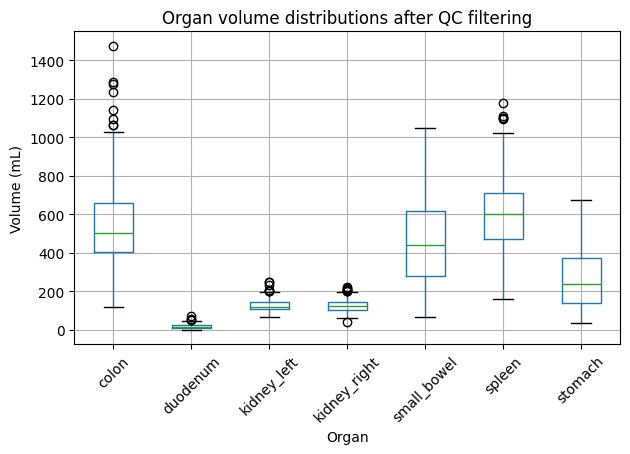

In [113]:
import matplotlib.pyplot as plt

plot_df = organ_long_qc_df[organ_long_qc_df["use_for_volume_stats"]].copy()

plt.figure(figsize=(10, 5))
plot_df.boxplot(column="volume_ml_qc", by="organ_name", rot=45)
plt.suptitle("")
plt.title("Organ volume distributions after QC filtering")
plt.xlabel("Organ")
plt.ylabel("Volume (mL)")
plt.tight_layout()
plt.show()

In [1]:
from pathlib import Path
import json
import pandas as pd

project_root = Path.cwd().resolve().parents[1]

config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

scan_root = Path(config["public_root"])
mask_root = Path(config["totalseg_root"])

scan_files = sorted(scan_root.glob("*.nii.gz"))
mask_files = sorted(mask_root.glob("*.nii.gz"))

scan_names = {p.name for p in scan_files}
mask_names = {p.name for p in mask_files}

missing_masks = sorted(scan_names - mask_names)
extra_masks = sorted(mask_names - scan_names)

sync_summary = {
    "n_scans": len(scan_files),
    "n_masks": len(mask_files),
    "n_missing_masks": len(missing_masks),
    "n_extra_masks": len(extra_masks),
}

sync_summary_df = pd.DataFrame([sync_summary])

missing_masks_df = pd.DataFrame({"file_name": missing_masks})
extra_masks_df = pd.DataFrame({"file_name": extra_masks})

sync_summary_df

,n_scans,n_masks,n_missing_masks,n_extra_masks
0,274,274,0,0


In [3]:
from pathlib import Path
import sys

def find_project_root(start_path=None):
    """
    Walk upward until we find the folder that contains src/.
    This is safer than using parents[1], because notebooks can be opened
    from different working directories.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = Path(start_path).resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "src").exists():
            return path

    raise FileNotFoundError("Could not find project root containing src/")

project_root = find_project_root()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Current working directory:", Path.cwd())
print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())

Current working directory: c:\Users\P102832\Downloads\thesis_segmentation\notebooks\01_eda
Project root: C:\Users\P102832\Downloads\thesis_segmentation
src exists: True


In [4]:
from src.eda.build_public_scan_inventory import save_scan_inventory

output_dir = project_root / "metadata" / "eda" / "final_base_level"
output_dir.mkdir(parents=True, exist_ok=True)

scan_inventory_path = output_dir / "scan_inventory_current_public_root.csv"

scan_inventory_df = save_scan_inventory(
    root_dir=scan_root,
    output_csv=scan_inventory_path,
)

print("Saved:", scan_inventory_path)
print("Number of scans:", len(scan_inventory_df))

scan_inventory_df.head()

Saved: C:\Users\P102832\Downloads\thesis_segmentation\metadata\eda\final_base_level\scan_inventory_current_public_root.csv
Number of scans: 274


,scan_id,file_name,relative_path,parent_folder,suffix,num_dimensions,shape,shape_x,shape_y,shape_z,...,max_intensity,mean_intensity,std_intensity,median_intensity,p01_intensity,p05_intensity,p95_intensity,p99_intensity,nonzero_fraction,error
0,case101_day20,case101_day20.nii.gz,case101_day20.nii.gz,NIFTI,.nii.gz,3,"(266, 266, 144)",266,266,144,...,1909.0,51.326859,77.999893,12.0,0.0,0.0,233.0,331.0,0.865128,None
1,case101_day22,case101_day22.nii.gz,case101_day22.nii.gz,NIFTI,.nii.gz,3,"(266, 266, 144)",266,266,144,...,1954.0,63.634525,99.307228,15.0,0.0,0.0,296.0,426.0,0.860109,None
2,case101_day26,case101_day26.nii.gz,case101_day26.nii.gz,NIFTI,.nii.gz,3,"(266, 266, 144)",266,266,144,...,15495.0,781.417603,1165.488770,180.0,0.0,0.0,3480.0,4845.0,0.858829,None
3,case101_day32,case101_day32.nii.gz,case101_day32.nii.gz,NIFTI,.nii.gz,3,"(266, 266, 144)",266,266,144,...,1315.0,65.700104,105.351112,9.0,0.0,0.0,310.0,435.0,0.846061,None
4,case102_day0,case102_day0.nii.gz,case102_day0.nii.gz,NIFTI,.nii.gz,3,"(360, 310, 144)",360,310,144,...,3205.0,40.928844,77.998779,4.0,0.0,0.0,220.0,321.0,0.700228,None
